In [1]:
import os
print(os.getcwd())

d:\SAMITH\Github\Image-Based-Food-Freshness-Prediction-System\notebooks


In [2]:
import sys
sys.path.append('..')

import os
import logging
from pathlib import Path
from src.config import Config
from src.utils import raw_img_dir
from PIL import Image
import tensorflow as tf 
import matplotlib.pyplot as plt 

### Loading the Data

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    '../artifacts/data/processed/train',
    label_mode='int',
    image_size=(224, 224),
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    '../artifacts/data/processed/val',
    label_mode='int',
    image_size=(224, 224),
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    '../artifacts/data/processed/test',
    label_mode='int',
    image_size=(224, 224),
    shuffle=False
)


Found 10363 files belonging to 2 classes.
Found 3157 files belonging to 2 classes.
Found 3138 files belonging to 2 classes.


In [4]:
batch = next(train_ds.as_numpy_iterator())

In [5]:
batch[0].shape

(32, 224, 224, 3)

In [6]:
batch[1]

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 1], dtype=int32)

In [7]:
class_names = train_ds.class_names
print(class_names)

['Fresh', 'Rotten']


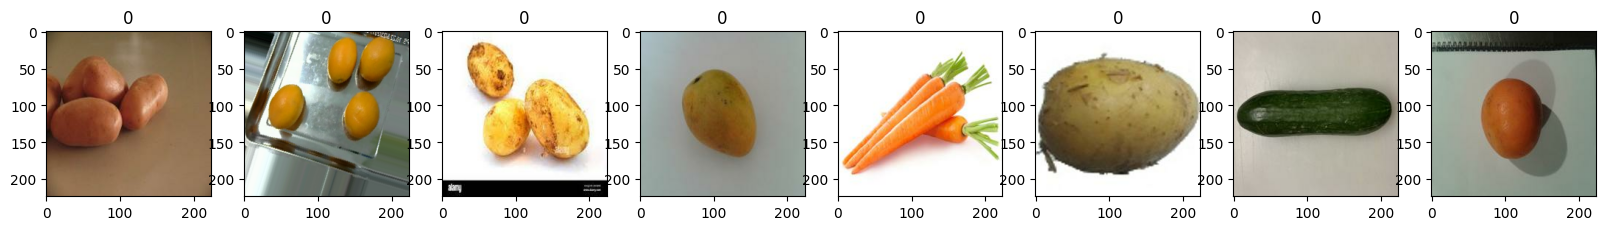

In [8]:
fig, ax = plt.subplots(ncols=8, figsize=(20,20))
for idx, img in enumerate(batch[0][:8]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

### Preprocess Data 

#### Scale Data 

In [9]:
train_ds = train_ds.map(lambda x, y: (x/255,y))
test_ds = test_ds.map(lambda x, y: (x/255,y))
val_ds = val_ds.map(lambda x, y: (x/255,y))

In [10]:
train_ds.as_numpy_iterator().next()[0].min()

np.float32(0.0)

### Model 

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [12]:
model = Sequential([  

    Input(shape=(224,224,3)),  

    Conv2D(16, (3,3), 1, activation='relu'),
    MaxPooling2D(),

    
    Conv2D(32, (3,3), 1, activation='relu'),
    MaxPooling2D(),

    Conv2D(16, (3,3), 1, activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(1, activation='sigmoid')

    ]
)

In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,769,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,779,121 (10.60 MB)

 Trainable params: 2,779,121 (10.60 MB)

 Non-trainable params: 0 (0.00 B)

### Training 

In [15]:
logdir ='logs'

In [16]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [17]:
hist = model.fit(train_ds, epochs=20, validation_data=val_ds, callbacks=[tensorboard_callback])

Epoch 1/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 179s 544ms/step - accuracy: 0.7036 - loss: 0.5600 - val_accuracy: 0.8191 - val_loss: 0.3977
Epoch 2/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 145s 448ms/step - accuracy: 0.8050 - loss: 0.4175 - val_accuracy: 0.8533 - val_loss: 0.3402
Epoch 3/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 121s 373ms/step - accuracy: 0.8577 - loss: 0.3233 - val_accuracy: 0.8600 - val_loss: 0.3292
Epoch 4/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 118s 364ms/step - accuracy: 0.8907 - loss: 0.2590 - val_accuracy: 0.9069 - val_loss: 0.2366
Epoch 5/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 112s 345ms/step - accuracy: 0.9212 - loss: 0.1987 - val_accuracy: 0.9297 - val_loss: 0.1928
Epoch 6/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 112s 346ms/step - accuracy: 0.9525 - loss: 0.1303 - val_accuracy: 0.9436 - val_loss: 0.1781
Epoch 7/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 116s 358ms/step - accuracy: 0.9660 - loss: 0.1011 - val_accuracy: 0.9576 - val_loss: 0.1473
Epoch 8/20
324/324 ━━━━━━━━━━━━━━━━━━━━ 114s 351ms/step - accuracy: 0.9764 -

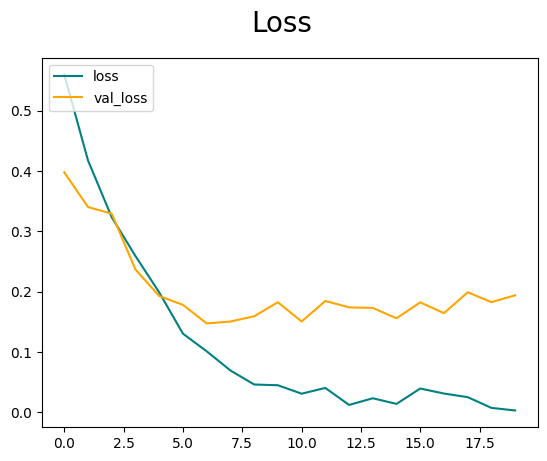

In [24]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc='upper left')
plt.show()


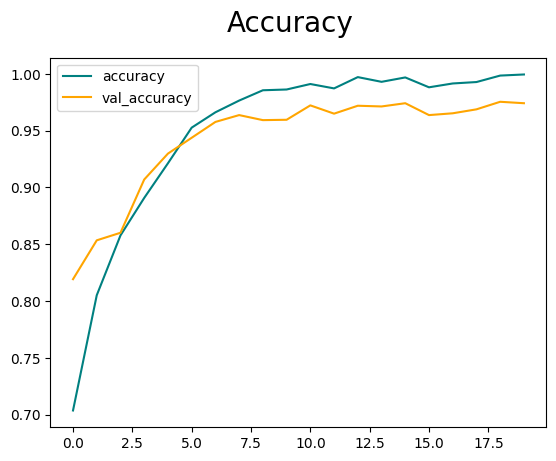

In [22]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc='upper left')
plt.show()

In [33]:
save_path = os.path.join('..', 'models', 'food_freshness_model.keras')
os.makedirs(os.path.dirname(save_path), exist_ok=True)

model.save(save_path)